In [120]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# HYPERPARAMETERS
# ============================================================================
N_SAMPLES = 100              # Number of datapoints to sample from the sine function
NOISE_LEVEL = 1.0           # Standard deviation of noise added to samples
N_FINETUNE = 10             # Number of closest points to use for fine-tuning
NUM_EPOCHS = 50              # Number of epochs for fine-tuning
NUM_REPETITIONS = 100       # Number of repetitions for average loss computation
LEARNING_RATE = 0.1         # Learning rate for fine-tuning
RANDOM_X_PERCENTAGE = 0.5   # Percentage of points to randomize x-values in Method 2 (0.0 to 1.0)
RANDOM_SEED = 42            # Random seed for reproducibility

# Set random seed
np.random.seed(RANDOM_SEED)


In [121]:
# ============================================================================
# SINE FUNCTION AND DATA GENERATION
# ============================================================================
def sine_func(x):
    """Sine function: f(x) = 3*sin(2*pi*x) + 2"""
    return 3 * np.sin(2 * np.pi * x) + 2

# Generate true curve for plotting
x_true = np.linspace(-2, 2, 1000)
y_true = sine_func(x_true)

# Sample datapoints with noise
x_samples = np.random.uniform(-2, 2, N_SAMPLES)
y_true_samples = sine_func(x_samples)
y_noisy = y_true_samples + np.random.normal(0, NOISE_LEVEL, N_SAMPLES)


In [122]:
# ============================================================================
# INITIAL LINEAR REGRESSION
# ============================================================================
# Fit linear regression on all noisy datapoints
X_samples = x_samples.reshape(-1, 1)
y_samples = y_noisy.reshape(-1, 1)

linear_model = LinearRegression()
linear_model.fit(X_samples, y_samples)
y_linear_pred = linear_model.predict(x_true.reshape(-1, 1))

print(f"Initial Linear Regression:")
print(f"  Slope: {linear_model.coef_[0][0]:.4f}")
print(f"  Intercept: {linear_model.intercept_[0]:.4f}")
print(f"  R² Score: {linear_model.score(X_samples, y_samples):.4f}")


Initial Linear Regression:
  Slope: -0.5258
  Intercept: 2.2285
  R² Score: 0.0690


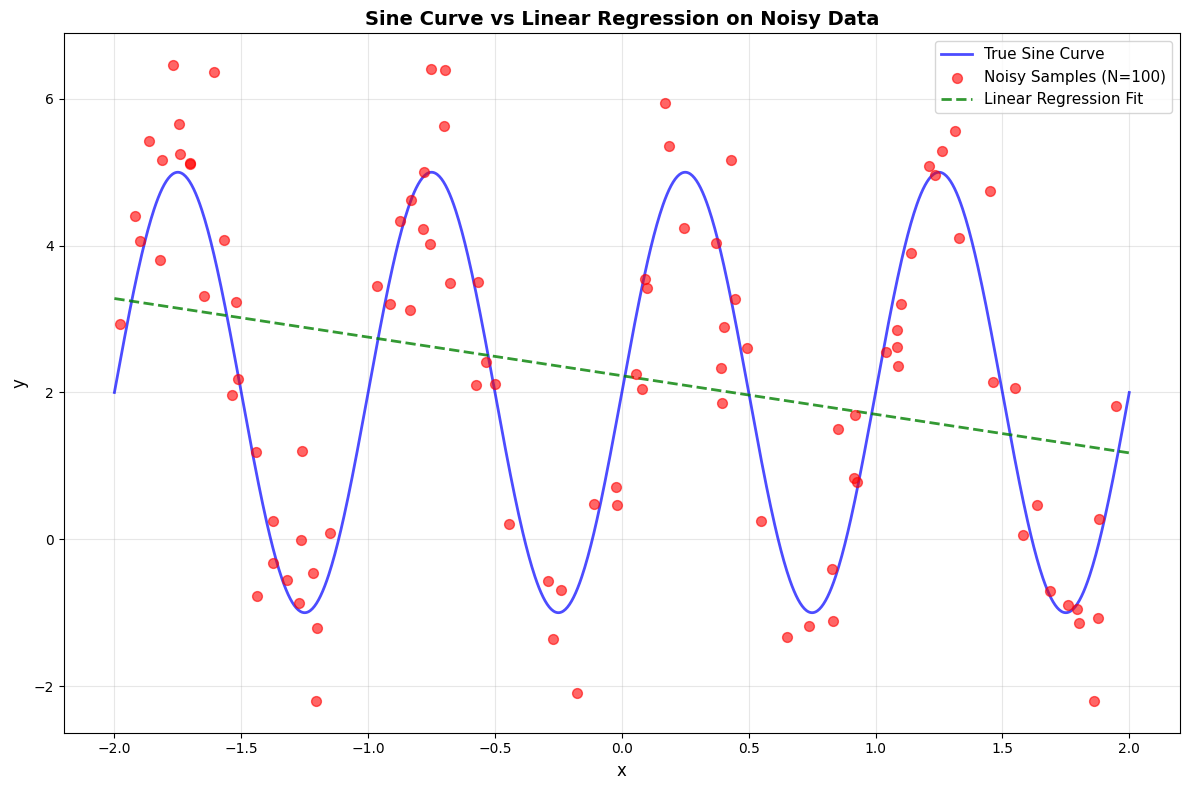

In [123]:
# ============================================================================
# VISUALIZATION: Initial Setup
# ============================================================================
plt.figure(figsize=(12, 8))
plt.plot(x_true, y_true, 'b-', linewidth=2, label='True Sine Curve', alpha=0.7)
plt.scatter(x_samples, y_noisy, color='red', s=50, alpha=0.6, label=f'Noisy Samples (N={N_SAMPLES})', zorder=5)
plt.plot(x_true, y_linear_pred, 'g--', linewidth=2, label='Linear Regression Fit', alpha=0.8)
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Sine Curve vs Linear Regression on Noisy Data', fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [124]:
# ============================================================================
# FINE-TUNING FUNCTIONS
# ============================================================================
def fine_tune_method1(x_finetune, y_finetune, epochs, lr):
    """Method 1: Fine-tune using actual x-values of selected points"""
    coef = linear_model.coef_[0][0].copy()
    intercept = linear_model.intercept_[0].copy()
    losses = []

    for epoch in range(epochs):
        y_pred = coef * x_finetune + intercept
        error = y_pred - y_finetune
        grad_coef = 2 * np.mean(error * x_finetune)
        grad_intercept = 2 * np.mean(error)
        coef -= lr * grad_coef
        intercept -= lr * grad_intercept
        losses.append(mean_squared_error(y_finetune, y_pred))
    return losses

def fine_tune_method2(x_finetune_original, y_finetune_original, x_finetune_random, random_indices, epochs, lr):
    """Method 2: Fine-tune using 50% random x-values (keeping original y-values), evaluate on original points

    Args:
        x_finetune_original: Original x-values of selected points
        y_finetune_original: Original y-values of selected points
        x_finetune_random: Random x-values (only used for indices in random_indices)
        random_indices: Indices of points to replace with random x-values (50% of points)
        epochs: Number of epochs
        lr: Learning rate
    """
    # Create mixed x-values: 50% original, 50% random
    x_finetune_mixed = x_finetune_original.copy()
    x_finetune_mixed[random_indices] = x_finetune_random[random_indices]

    # Keep original y-values for all points (including those with randomized x)
    y_finetune_mixed = y_finetune_original.copy()

    coef = linear_model.coef_[0][0].copy()
    intercept = linear_model.intercept_[0].copy()
    losses = []

    for epoch in range(epochs):
        # Train on mixed x-values (50% original, 50% random) with original y-values
        y_pred_train = coef * x_finetune_mixed + intercept
        error = y_pred_train - y_finetune_mixed
        grad_coef = 2 * np.mean(error * x_finetune_mixed)
        grad_intercept = 2 * np.mean(error)
        coef -= lr * grad_coef
        intercept -= lr * grad_intercept
        # Evaluate on original points
        y_pred_original = coef * x_finetune_original + intercept
        losses.append(mean_squared_error(y_finetune_original, y_pred_original))
    return losses


In [125]:
# ============================================================================
# REPEATED EXPERIMENTS: Compare Fine-tuning Methods
# ============================================================================
all_losses_method1, all_losses_method2 = [], []

print(f"Running {NUM_REPETITIONS} repetitions...")
for run in range(NUM_REPETITIONS):
    # Set seed for this run to get same query point for both methods
    np.random.seed(1000 + run)
    x_query = np.random.uniform(-2, 2)

    # Find closest points
    distances = np.abs(x_samples - x_query)
    closest_indices = np.argsort(distances)[:N_FINETUNE]
    x_finetune = x_samples[closest_indices]
    y_finetune = y_noisy[closest_indices]

    # Method 1: Actual x-values
    losses1 = fine_tune_method1(x_finetune, y_finetune, NUM_EPOCHS, LEARNING_RATE)
    all_losses_method1.append(losses1)

    # Method 2: Random x-values (same selected points)
    np.random.seed(1000 + run)  # Same seed to get same query point
    x_query2 = np.random.uniform(-2, 2)
    distances2 = np.abs(x_samples - x_query2)
    closest_indices2 = np.argsort(distances2)[:N_FINETUNE]
    x_finetune_original = x_samples[closest_indices2]
    y_finetune2 = y_noisy[closest_indices2]

    # Generate random x-values for training (50% replacement)
    np.random.seed(2000 + run)
    x_finetune_random = np.random.uniform(-2, 2, N_FINETUNE)

    # Select 50% of indices to replace with random x-values
    n_replace = N_FINETUNE // 2
    random_indices = np.random.choice(N_FINETUNE, size=n_replace, replace=False)

    losses2 = fine_tune_method2(x_finetune_original, y_finetune2, x_finetune_random, random_indices, NUM_EPOCHS, LEARNING_RATE)
    all_losses_method2.append(losses2)

    if (run + 1) % 10 == 0:
        print(f"  Completed {run + 1}/{NUM_REPETITIONS} runs...")

print("Done!")


Running 100 repetitions...
  Completed 10/100 runs...
  Completed 20/100 runs...
  Completed 30/100 runs...
  Completed 40/100 runs...
  Completed 50/100 runs...
  Completed 60/100 runs...
  Completed 70/100 runs...
  Completed 80/100 runs...
  Completed 90/100 runs...
  Completed 100/100 runs...
Done!


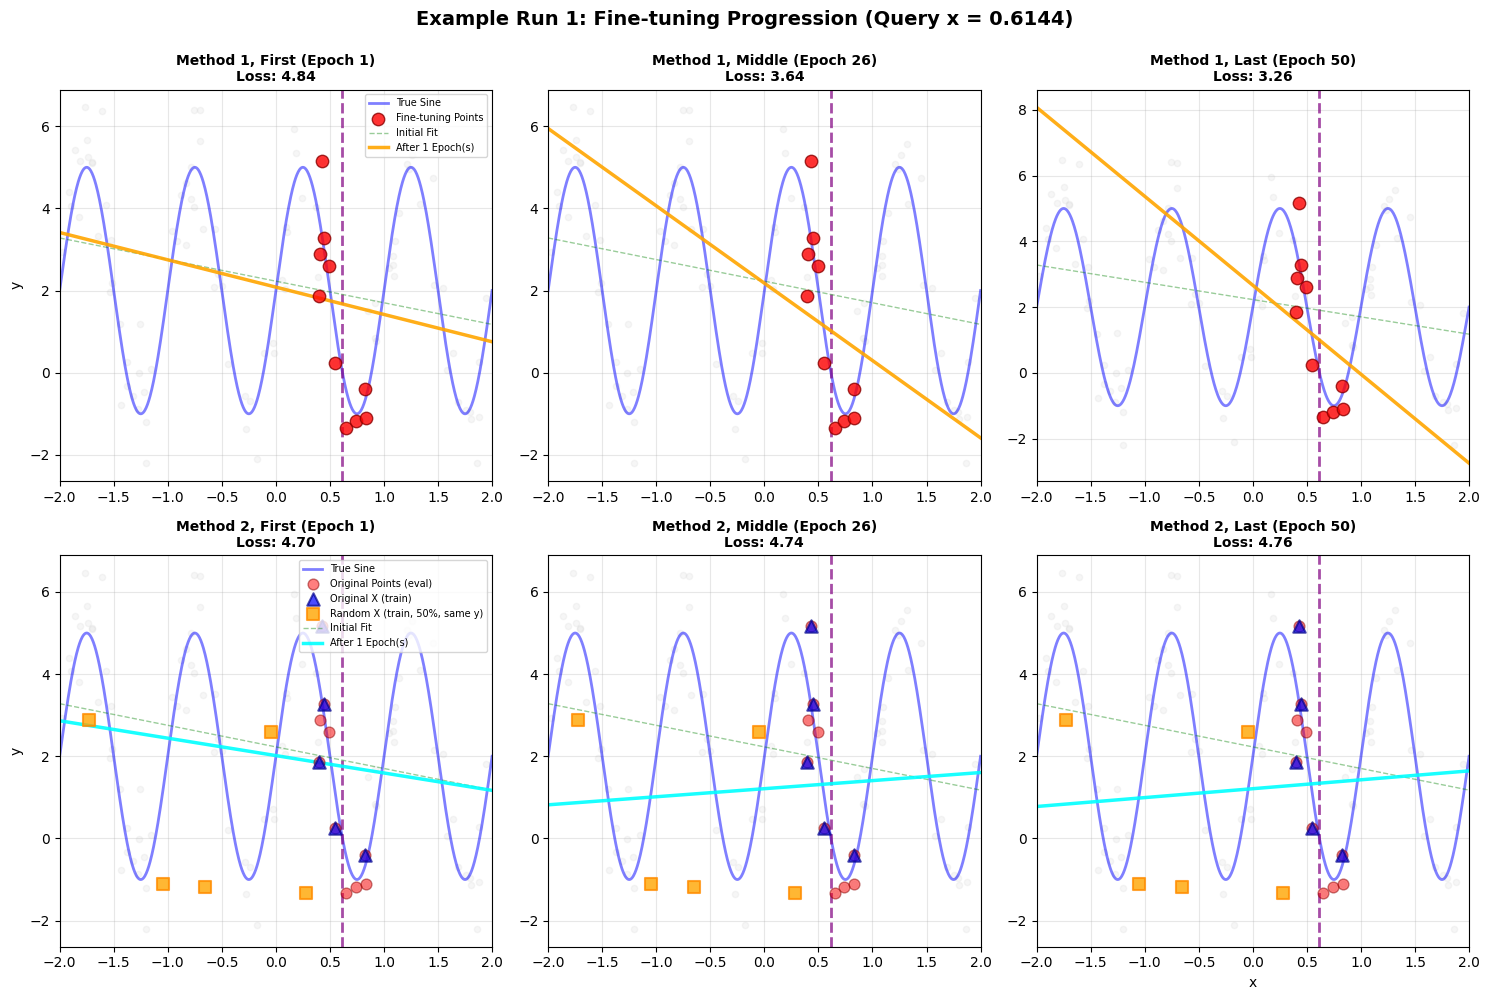

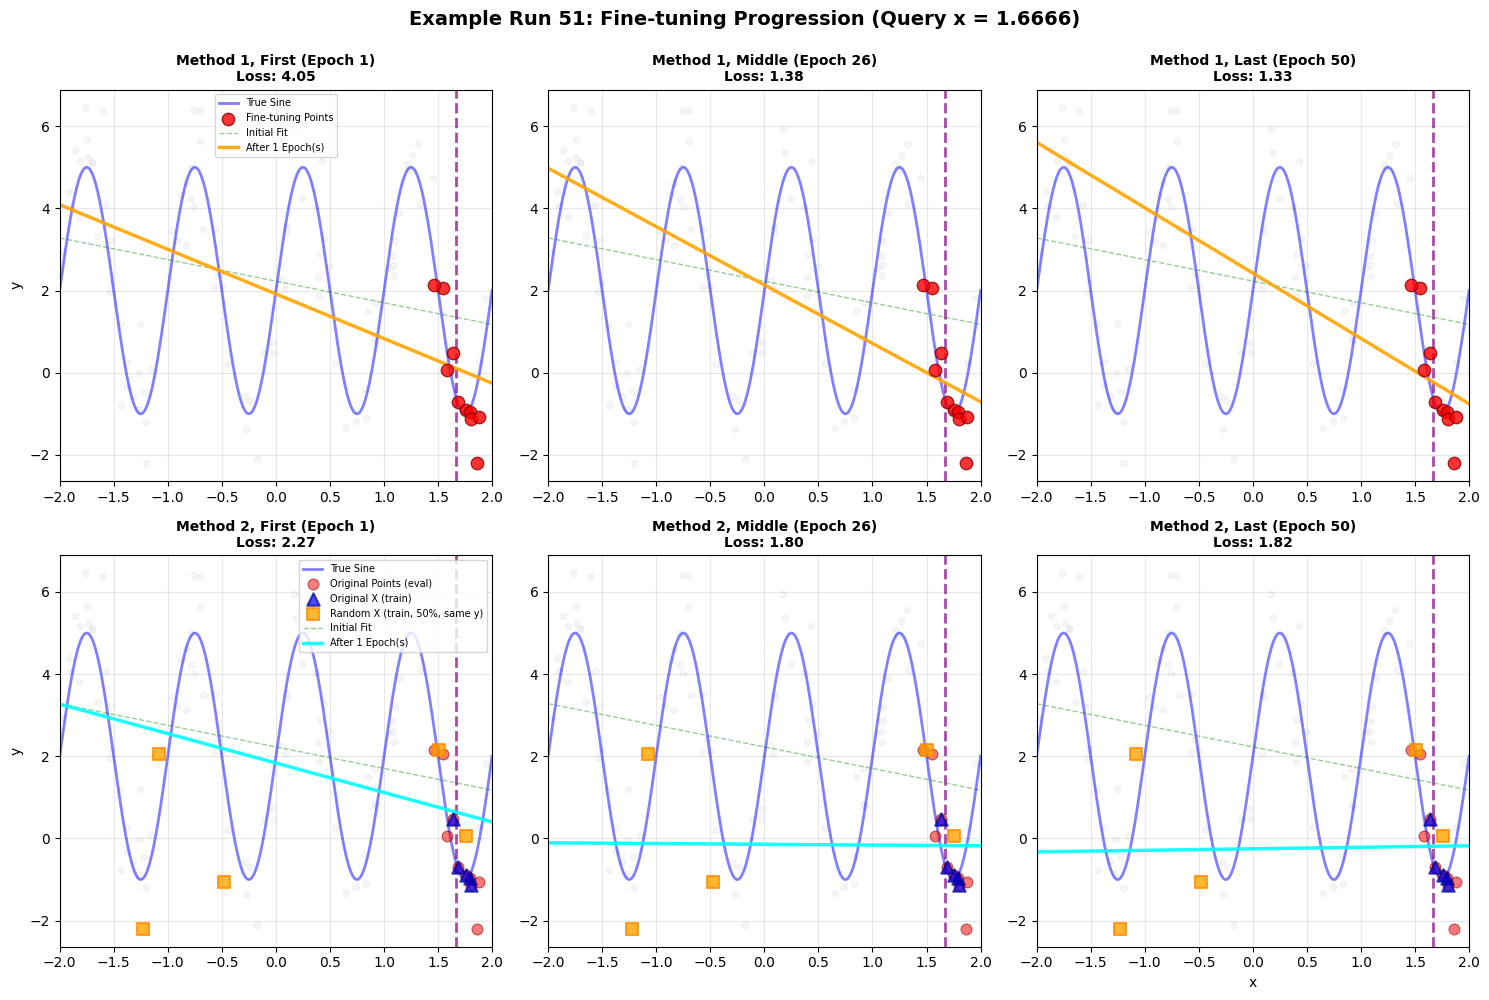

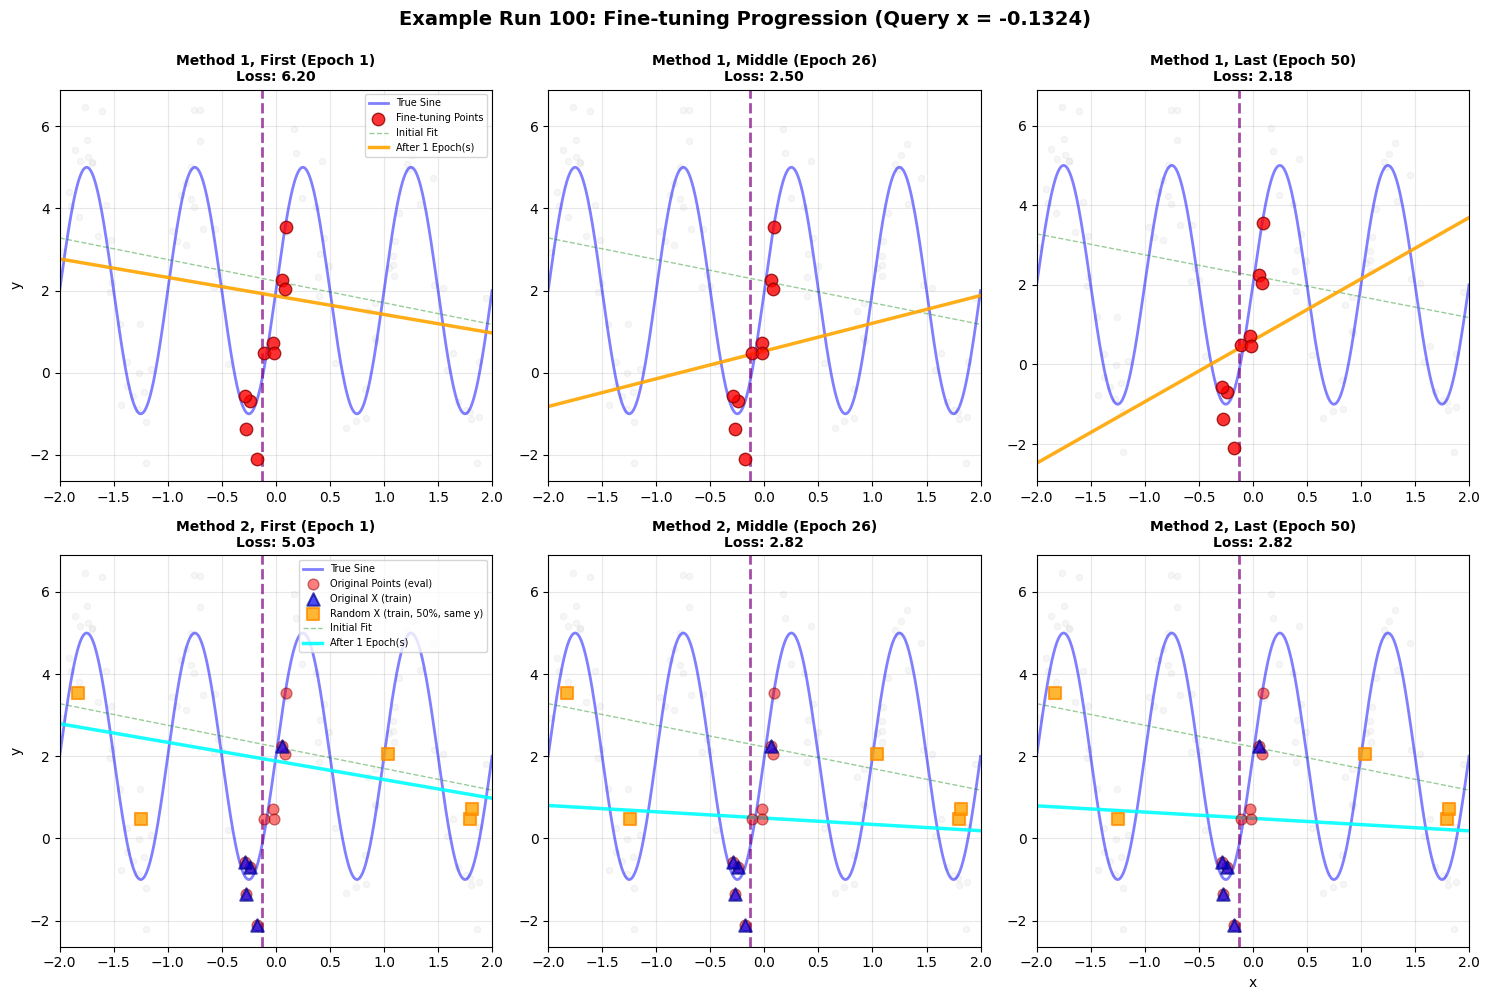


Average Losses Over 100 Runs

Method 1 (Actual X-values):
  Epoch 1: 5.0328 ± 1.9452
  Epoch 2: 3.3884 ± 1.2884
  Epoch 3: 2.9125 ± 1.2617
  Epoch 4: 2.7041 ± 1.2586
  Epoch 5: 2.5962 ± 1.2567
  Epoch 6: 2.5346 ± 1.2554
  Epoch 7: 2.4970 ± 1.2536
  Epoch 8: 2.4725 ± 1.2509
  Epoch 9: 2.4556 ± 1.2475
  Epoch 10: 2.4432 ± 1.2434
  Epoch 11: 2.4334 ± 1.2389
  Epoch 12: 2.4252 ± 1.2342
  Epoch 13: 2.4180 ± 1.2293
  Epoch 14: 2.4114 ± 1.2244
  Epoch 15: 2.4052 ± 1.2194
  Epoch 16: 2.3992 ± 1.2143
  Epoch 17: 2.3934 ± 1.2094
  Epoch 18: 2.3877 ± 1.2044
  Epoch 19: 2.3821 ± 1.1994
  Epoch 20: 2.3766 ± 1.1945
  Epoch 21: 2.3711 ± 1.1897
  Epoch 22: 2.3656 ± 1.1849
  Epoch 23: 2.3602 ± 1.1801
  Epoch 24: 2.3548 ± 1.1754
  Epoch 25: 2.3495 ± 1.1707
  Epoch 26: 2.3442 ± 1.1660
  Epoch 27: 2.3389 ± 1.1614
  Epoch 28: 2.3336 ± 1.1568
  Epoch 29: 2.3284 ± 1.1523
  Epoch 30: 2.3232 ± 1.1478
  Epoch 31: 2.3180 ± 1.1434
  Epoch 32: 2.3129 ± 1.1390
  Epoch 33: 2.3078 ± 1.1346
  Epoch 34: 2.3027 ± 1.130

In [126]:
# ============================================================================
# SAMPLE VISUALIZATIONS: Show Fine-tuning Progression for Example Runs
# ============================================================================
NUM_EXAMPLES = 3  # Number of example runs to visualize

# Select a few example runs to visualize
example_runs = [0, NUM_REPETITIONS // 2, NUM_REPETITIONS - 1]  # First, middle, last

for example_idx, run_idx in enumerate(example_runs[:NUM_EXAMPLES]):
    # Recreate the same conditions for this run
    np.random.seed(1000 + run_idx)
    x_query_example = np.random.uniform(-2, 2)

    # Find closest points
    distances_example = np.abs(x_samples - x_query_example)
    closest_indices_example = np.argsort(distances_example)[:N_FINETUNE]
    x_finetune_example = x_samples[closest_indices_example]
    y_finetune_example = y_noisy[closest_indices_example]

    # Method 1: Fine-tune and store predictions
    coef1 = linear_model.coef_[0][0].copy()
    intercept1 = linear_model.intercept_[0].copy()
    predictions_method1 = []

    for epoch in range(NUM_EPOCHS):
        y_pred1 = coef1 * x_finetune_example + intercept1
        error1 = y_pred1 - y_finetune_example
        grad_coef1 = 2 * np.mean(error1 * x_finetune_example)
        grad_intercept1 = 2 * np.mean(error1)
        coef1 -= LEARNING_RATE * grad_coef1
        intercept1 -= LEARNING_RATE * grad_intercept1
        predictions_method1.append(coef1 * x_true + intercept1)

    # Method 2: Fine-tune with 50% random x-values
    np.random.seed(1000 + run_idx)
    x_query_example2 = np.random.uniform(-2, 2)
    distances_example2 = np.abs(x_samples - x_query_example2)
    closest_indices_example2 = np.argsort(distances_example2)[:N_FINETUNE]
    x_finetune_original_example = x_samples[closest_indices_example2]
    y_finetune_example2 = y_noisy[closest_indices_example2]

    np.random.seed(2000 + run_idx)
    x_finetune_random_example = np.random.uniform(-2, 2, N_FINETUNE)

    # Select percentage of indices to replace with random x-values
    n_replace = int(N_FINETUNE * RANDOM_X_PERCENTAGE)
    random_indices_example = np.random.choice(N_FINETUNE, size=n_replace, replace=False)

    # Create mixed x-values: some original, some random (based on random_indices)
    x_finetune_mixed_example = x_finetune_original_example.copy()
    x_finetune_mixed_example[random_indices_example] = x_finetune_random_example[random_indices_example]

    # Keep original y-values for all points (including those with randomized x)
    y_finetune_mixed_example = y_finetune_example2.copy()

    coef2 = linear_model.coef_[0][0].copy()
    intercept2 = linear_model.intercept_[0].copy()
    predictions_method2 = []

    for epoch in range(NUM_EPOCHS):
        # Train on mixed x-values with original y-values
        y_pred_train = coef2 * x_finetune_mixed_example + intercept2
        error2 = y_pred_train - y_finetune_mixed_example
        grad_coef2 = 2 * np.mean(error2 * x_finetune_mixed_example)
        grad_intercept2 = 2 * np.mean(error2)
        coef2 -= LEARNING_RATE * grad_coef2
        intercept2 -= LEARNING_RATE * grad_intercept2
        predictions_method2.append(coef2 * x_true + intercept2)

    # Plot only first, middle, and last epochs
    epochs_to_plot = [0, NUM_EPOCHS // 2, NUM_EPOCHS - 1]
    epoch_labels = ['First', 'Middle', 'Last']

    fig, axes = plt.subplots(2, len(epochs_to_plot), figsize=(5*len(epochs_to_plot), 10))

    for plot_idx, epoch in enumerate(epochs_to_plot):
        # Method 1 (top row)
        ax1 = axes[0, plot_idx]
        ax1.plot(x_true, y_true, 'b-', linewidth=2, label='True Sine', alpha=0.5)
        ax1.scatter(x_samples, y_noisy, color='lightgray', s=20, alpha=0.2)
        ax1.scatter(x_finetune_example, y_finetune_example, color='red', s=80, alpha=0.8,
                   label=f'Fine-tuning Points', zorder=5, edgecolors='darkred', linewidths=1)
        ax1.axvline(x_query_example, color='purple', linestyle='--', linewidth=2, alpha=0.7)
        ax1.plot(x_true, y_linear_pred, 'g--', linewidth=1, alpha=0.4, label='Initial Fit')
        ax1.plot(x_true, predictions_method1[epoch], 'orange', linewidth=2.5, label=f'After {epoch+1} Epoch(s)', alpha=0.9)
        ax1.set_title(f'Method 1, {epoch_labels[plot_idx]} (Epoch {epoch+1})\nLoss: {all_losses_method1[run_idx][epoch]:.2f}',
                     fontsize=10, fontweight='bold')
        ax1.set_xlim(-2, 2)
        ax1.grid(True, alpha=0.3)
        if plot_idx == 0:
            ax1.set_ylabel('y', fontsize=10)
            ax1.legend(fontsize=7, loc='best')

        # Method 2 (bottom row)
        ax2 = axes[1, plot_idx]
        ax2.plot(x_true, y_true, 'b-', linewidth=2, label='True Sine', alpha=0.5)
        ax2.scatter(x_samples, y_noisy, color='lightgray', s=20, alpha=0.2)
        # Show original points (all of them, for evaluation)
        ax2.scatter(x_finetune_original_example, y_finetune_example2, color='red', s=60, alpha=0.5,
                   label='Original Points (eval)', zorder=4, marker='o', edgecolors='darkred', linewidths=1)
        # Show points with original x (not replaced)
        original_mask = ~np.isin(np.arange(N_FINETUNE), random_indices_example)
        if original_mask.sum() > 0:
            ax2.scatter(x_finetune_original_example[original_mask], y_finetune_example2[original_mask],
                       color='blue', s=80, alpha=0.7, label='Original X (train)', zorder=5,
                       marker='^', edgecolors='darkblue', linewidths=1.5)
        # Show points with random x (replaced, but keeping original y)
        if random_indices_example.size > 0:
            ax2.scatter(x_finetune_random_example[random_indices_example],
                       y_finetune_example2[random_indices_example],
                       color='orange', s=80, alpha=0.8,
                       label=f'Random X (train, {int(RANDOM_X_PERCENTAGE*100)}%, same y)', zorder=5,
                       marker='s', edgecolors='darkorange', linewidths=1.5)
        ax2.axvline(x_query_example2, color='purple', linestyle='--', linewidth=2, alpha=0.7)
        ax2.plot(x_true, y_linear_pred, 'g--', linewidth=1, alpha=0.4, label='Initial Fit')
        ax2.plot(x_true, predictions_method2[epoch], 'cyan', linewidth=2.5,
                label=f'After {epoch+1} Epoch(s)', alpha=0.9)
        ax2.set_title(f'Method 2, {epoch_labels[plot_idx]} (Epoch {epoch+1})\nLoss: {all_losses_method2[run_idx][epoch]:.2f}', fontsize=10, fontweight='bold')
        ax2.set_xlim(-2, 2)
        ax2.grid(True, alpha=0.3)
        if plot_idx == 0:
            ax2.set_ylabel('y', fontsize=10)
            ax2.legend(fontsize=7, loc='best')
        if plot_idx == len(epochs_to_plot) - 1:
            ax2.set_xlabel('x', fontsize=10)

    plt.suptitle(f'Example Run {run_idx + 1}: Fine-tuning Progression (Query x = {x_query_example:.4f})',
                fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()

# ============================================================================
# COMPUTE STATISTICS
# ============================================================================
all_losses_method1 = np.array(all_losses_method1)
all_losses_method2 = np.array(all_losses_method2)

mean_losses1 = np.mean(all_losses_method1, axis=0)
std_losses1 = np.std(all_losses_method1, axis=0)
mean_losses2 = np.mean(all_losses_method2, axis=0)
std_losses2 = np.std(all_losses_method2, axis=0)

epochs = np.arange(1, NUM_EPOCHS + 1)

# Print statistics
print(f"\n{'='*60}")
print(f"Average Losses Over {NUM_REPETITIONS} Runs")
print(f"{'='*60}")
print(f"\nMethod 1 (Actual X-values):")
for i, (m, s) in enumerate(zip(mean_losses1, std_losses1)):
    print(f"  Epoch {i+1}: {m:.4f} ± {s:.4f}")

print(f"\nMethod 2 (Random X-values):")
for i, (m, s) in enumerate(zip(mean_losses2, std_losses2)):
    print(f"  Epoch {i+1}: {m:.4f} ± {s:.4f}")

print(f"\nFinal Comparison (Epoch {NUM_EPOCHS}):")
print(f"  Method 1: {mean_losses1[-1]:.4f} ± {std_losses1[-1]:.4f}")
print(f"  Method 2: {mean_losses2[-1]:.4f} ± {std_losses2[-1]:.4f}")
print(f"  Difference: {mean_losses2[-1] - mean_losses1[-1]:.4f}")


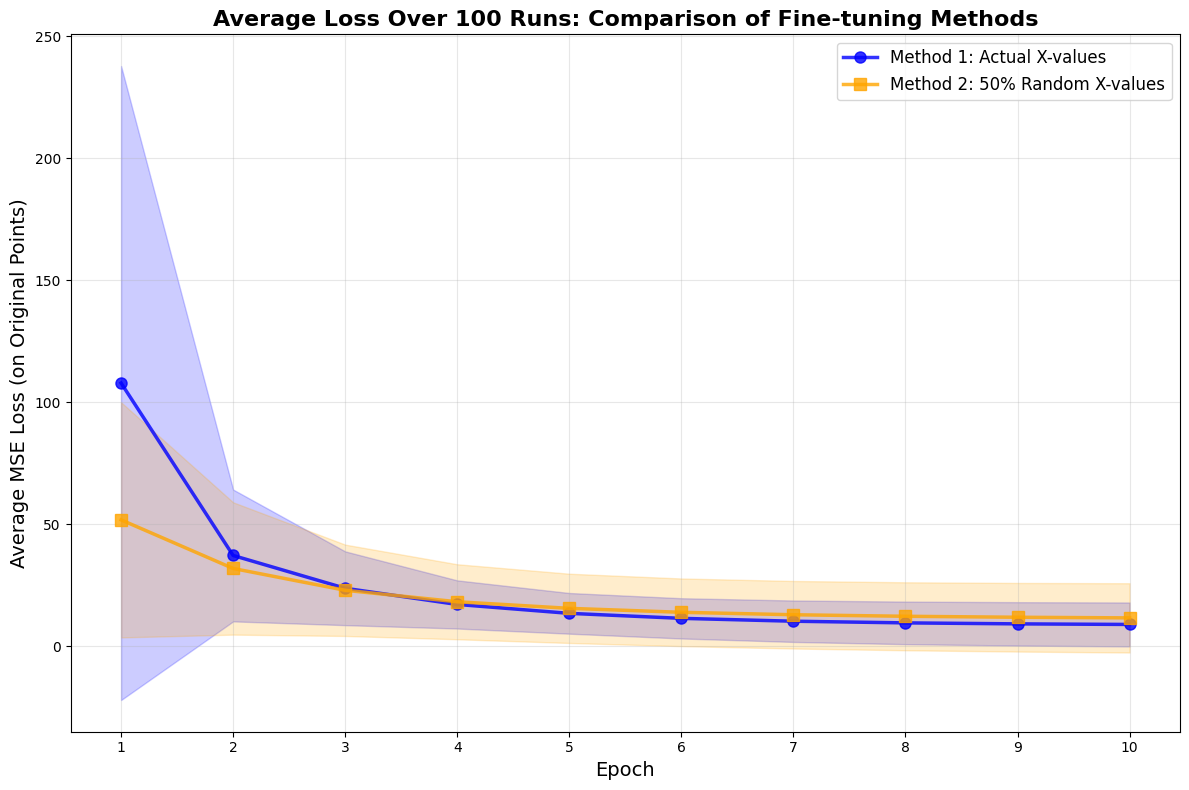

In [ ]:
# ============================================================================
# PLOT RESULTS
# ============================================================================
plt.figure(figsize=(12, 8))
plt.plot(epochs, mean_losses1, 'o-', linewidth=2.5, markersize=8,
         color='blue', label='Method 1: Actual X-values', alpha=0.8)
plt.fill_between(epochs, mean_losses1 - std_losses1, mean_losses1 + std_losses1,
                 alpha=0.2, color='blue')
plt.plot(epochs, mean_losses2, 's-', linewidth=2.5, markersize=8,
         color='orange', label='Method 2: Random X-values', alpha=0.8)
plt.fill_between(epochs, mean_losses2 - std_losses2, mean_losses2 + std_losses2,
                 alpha=0.2, color='orange')
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Average MSE Loss (on Original Points)', fontsize=14)
plt.title(f'Average Loss Over {NUM_REPETITIONS} Runs: Comparison of Fine-tuning Methods',
          fontsize=16, fontweight='bold')
plt.legend(fontsize=12, loc='best')
plt.grid(True, alpha=0.3)
plt.xticks(epochs)
plt.tight_layout()
plt.show()


In [90]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# HYPERPARAMETERS
# ============================================================================
N_SAMPLES = 100              # Number of datapoints to sample from the polynomial
NOISE_LEVEL = 2.0           # Standard deviation of noise added to samples
N_FINETUNE = 10             # Number of closest points to use for fine-tuning
NUM_EPOCHS = 5              # Number of epochs for fine-tuning
NUM_REPETITIONS = 100       # Number of repetitions for average loss computation
LEARNING_RATE = 0.1         # Learning rate for fine-tuning
RANDOM_SEED = 42            # Random seed for reproducibility

# Set random seed
np.random.seed(RANDOM_SEED)


In [91]:
# ============================================================================
# POLYNOMIAL FUNCTION AND DATA GENERATION
# ============================================================================
def polynomial_func(x):
    """Complex polynomial: f(x) = 2x^4 - 3x^3 + x^2 - 0.5x + 1"""
    return 2*x**4 - 3*x**3 + x**2 - 0.5*x + 1

# Generate true curve for plotting
x_true = np.linspace(-2, 2, 1000)
y_true = polynomial_func(x_true)

# Sample datapoints with noise
x_samples = np.random.uniform(-2, 2, N_SAMPLES)
y_true_samples = polynomial_func(x_samples)
y_noisy = y_true_samples + np.random.normal(0, NOISE_LEVEL, N_SAMPLES)


In [92]:
# ============================================================================
# INITIAL LINEAR REGRESSION
# ============================================================================
# Fit linear regression on all noisy datapoints
X_samples = x_samples.reshape(-1, 1)
y_samples = y_noisy.reshape(-1, 1)

linear_model = LinearRegression()
linear_model.fit(X_samples, y_samples)
y_linear_pred = linear_model.predict(x_true.reshape(-1, 1))

print(f"Initial Linear Regression:")
print(f"  Slope: {linear_model.coef_[0][0]:.4f}")
print(f"  Intercept: {linear_model.intercept_[0]:.4f}")
print(f"  R² Score: {linear_model.score(X_samples, y_samples):.4f}")


Initial Linear Regression:
  Slope: -8.7527
  Intercept: 9.2112
  R² Score: 0.4737


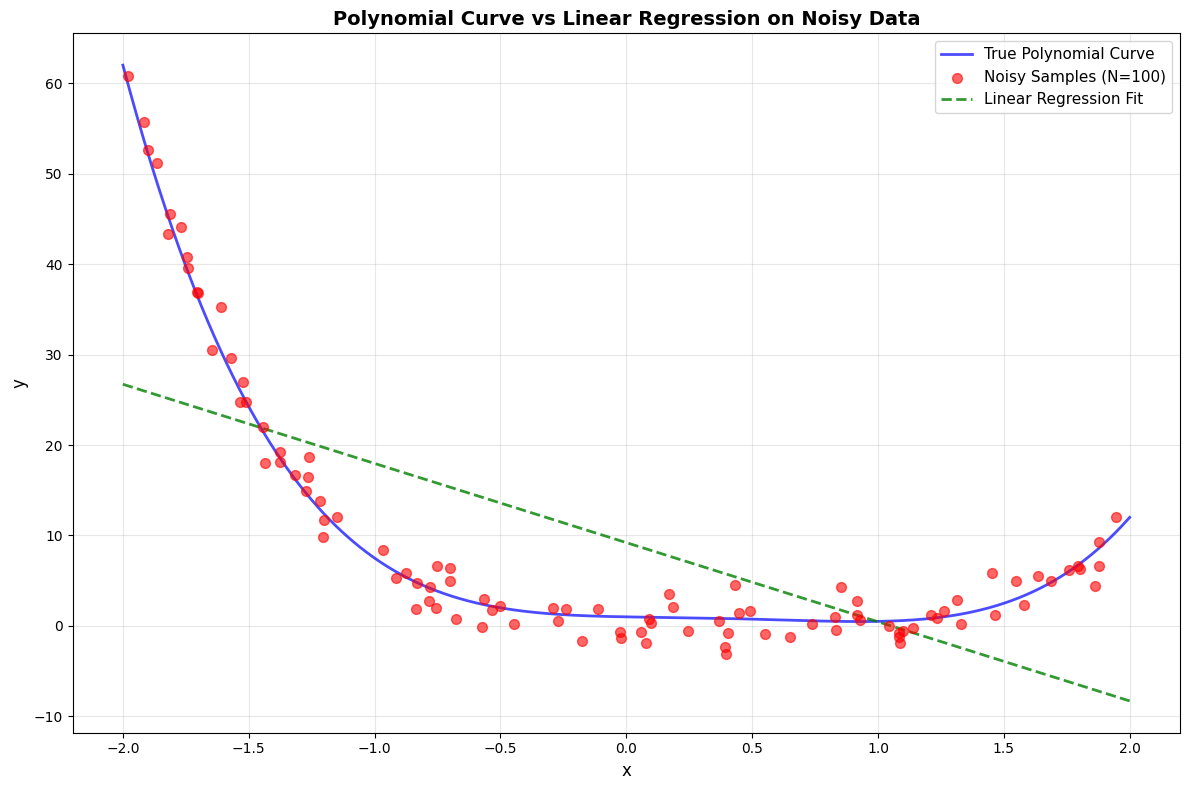

In [93]:
# ============================================================================
# VISUALIZATION: Initial Setup
# ============================================================================
plt.figure(figsize=(12, 8))
plt.plot(x_true, y_true, 'b-', linewidth=2, label='True Polynomial Curve', alpha=0.7)
plt.scatter(x_samples, y_noisy, color='red', s=50, alpha=0.6, label=f'Noisy Samples (N={N_SAMPLES})', zorder=5)
plt.plot(x_true, y_linear_pred, 'g--', linewidth=2, label='Linear Regression Fit', alpha=0.8)
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Polynomial Curve vs Linear Regression on Noisy Data', fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [94]:
# ============================================================================
# COMPUTE STATISTICS AND PLOT RESULTS
# ============================================================================
all_losses_method1 = np.array(all_losses_method1)
all_losses_method2 = np.array(all_losses_method2)

mean_losses1 = np.mean(all_losses_method1, axis=0)
std_losses1 = np.std(all_losses_method1, axis=0)
mean_losses2 = np.mean(all_losses_method2, axis=0)
std_losses2 = np.std(all_losses_method2, axis=0)

epochs = np.arange(1, NUM_EPOCHS + 1)

# Print statistics
print(f"\n{'='*60}")
print(f"Average Losses Over {NUM_REPETITIONS} Runs")
print(f"{'='*60}")
print(f"\nMethod 1 (Actual X-values):")
for i, (m, s) in enumerate(zip(mean_losses1, std_losses1)):
    print(f"  Epoch {i+1}: {m:.4f} ± {s:.4f}")

print(f"\nMethod 2 (Random X-values):")
for i, (m, s) in enumerate(zip(mean_losses2, std_losses2)):
    print(f"  Epoch {i+1}: {m:.4f} ± {s:.4f}")

print(f"\nFinal Comparison (Epoch {NUM_EPOCHS}):")
print(f"  Method 1: {mean_losses1[-1]:.4f} ± {std_losses1[-1]:.4f}")
print(f"  Method 2: {mean_losses2[-1]:.4f} ± {std_losses2[-1]:.4f}")
print(f"  Difference: {mean_losses2[-1] - mean_losses1[-1]:.4f}")



Average Losses Over 100 Runs

Method 1 (Actual X-values):
  Epoch 1: 107.8102 ± 129.9544
  Epoch 2: 37.1104 ± 27.0195
  Epoch 3: 23.6712 ± 15.1197
  Epoch 4: 17.0343 ± 9.8685
  Epoch 5: 13.3897 ± 8.3388
  Epoch 6: 11.3377 ± 8.2524
  Epoch 7: 10.1628 ± 8.4909
  Epoch 8: 9.4800 ± 8.7245
  Epoch 9: 9.0775 ± 8.8934
  Epoch 10: 8.8367 ± 9.0040

Method 2 (Random X-values):
  Epoch 1: 61.7239 ± 55.6763
  Epoch 2: 43.8212 ± 36.4711
  Epoch 3: 35.1720 ± 29.6039
  Epoch 4: 30.3112 ± 26.5197
  Epoch 5: 27.3112 ± 24.9873
  Epoch 6: 25.3465 ± 24.1766
  Epoch 7: 24.0065 ± 23.7201
  Epoch 8: 23.0645 ± 23.4448
  Epoch 9: 22.3866 ± 23.2668
  Epoch 10: 21.8892 ± 23.1439

Final Comparison (Epoch 5):
  Method 1: 8.8367 ± 9.0040
  Method 2: 21.8892 ± 23.1439
  Difference: 13.0525


ValueError: x and y must have same first dimension, but have shapes (5,) and (10,)

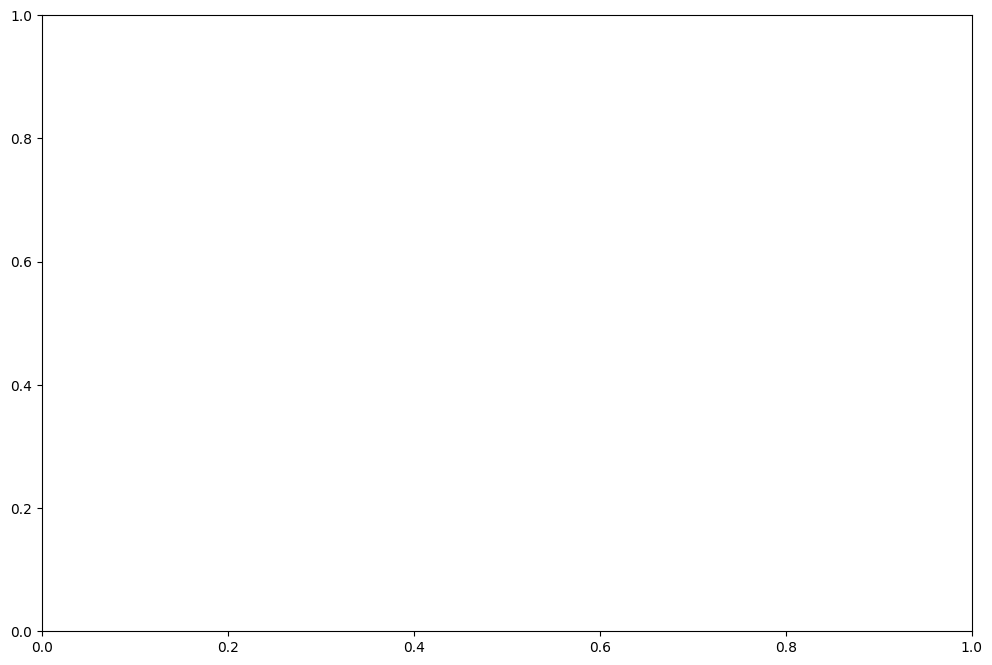

In [95]:
# Plot average loss curves with error bars
plt.figure(figsize=(12, 8))
plt.plot(epochs, mean_losses1, 'o-', linewidth=2.5, markersize=8,
         color='blue', label='Method 1: Actual X-values', alpha=0.8)
plt.fill_between(epochs, mean_losses1 - std_losses1, mean_losses1 + std_losses1,
                 alpha=0.2, color='blue')
plt.plot(epochs, mean_losses2, 's-', linewidth=2.5, markersize=8,
         color='orange', label='Method 2: Random X-values', alpha=0.8)
plt.fill_between(epochs, mean_losses2 - std_losses2, mean_losses2 + std_losses2,
                 alpha=0.2, color='orange')
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Average MSE Loss (on Original Points)', fontsize=14)
plt.title(f'Average Loss Over {NUM_REPETITIONS} Runs: Comparison of Fine-tuning Methods',
          fontsize=16, fontweight='bold')
plt.legend(fontsize=12, loc='best')
plt.grid(True, alpha=0.3)
plt.xticks(epochs)
plt.tight_layout()
plt.show()


In [ ]:
# Visualize the fine-tuning progression
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# Plot for each epoch (1, 2, ..., E)
for idx, epoch in enumerate(range(1, E + 1)):
    ax = axes[idx]

    # Plot true polynomial curve
    ax.plot(x_true, y_true, 'b-', linewidth=2, label='True Polynomial', alpha=0.5)

    # Plot all original datapoints (light gray)
    ax.scatter(x_samples, y_noisy, color='lightgray', s=30, alpha=0.3, label='All Data')

    # Highlight fine-tuning points
    ax.scatter(x_finetune, y_finetune, color='red', s=100, alpha=0.8,
               label=f'Fine-tuning Points (N={N_finetune})', zorder=5, edgecolors='darkred', linewidths=1.5)

    # Mark the query point
    ax.axvline(x_query, color='purple', linestyle='--', linewidth=2, alpha=0.7, label='Query Point')

    # Plot initial linear fit
    ax.plot(x_true, y_linear_pred, 'g--', linewidth=1.5, alpha=0.5, label='Initial Fit')

    # Plot fine-tuned fit at this epoch
    ax.plot(x_true, fine_tuned_predictions[epoch-1], 'orange', linewidth=2.5,
            label=f'After {epoch} Epoch(s)', alpha=0.9)

    ax.set_xlabel('x', fontsize=10)
    ax.set_ylabel('y', fontsize=10)
    ax.set_title(f'Epoch {epoch} (Loss: {fine_tuned_losses[epoch-1]:.4f})', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8, loc='best')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-2, 2)

plt.tight_layout()
plt.suptitle(f'Fine-tuning Progression (Query x = {x_query:.4f})', fontsize=14, fontweight='bold', y=1.02)
plt.show()


In [ ]:
# Plot loss curve during fine-tuning
plt.figure(figsize=(10, 6))
epochs = np.arange(1, E + 1)
plt.plot(epochs, fine_tuned_losses, 'o-', linewidth=2, markersize=8, color='red')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('MSE Loss on Fine-tuning Data', fontsize=12)
plt.title('Fine-tuning Loss Progression', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(epochs)
plt.tight_layout()
plt.show()

print(f"\nInitial loss (before fine-tuning): {mean_squared_error(y_finetune, linear_model.predict(X_finetune)):.4f}")
print(f"Final loss (after {E} epochs): {fine_tuned_losses[-1]:.4f}")
print(f"Improvement: {mean_squared_error(y_finetune, linear_model.predict(X_finetune)) - fine_tuned_losses[-1]:.4f}")


## New Procedure: Fine-tuning with Random X-values

This procedure selects the N closest points to a query, but then uses **random x-values** (in the same range) for fine-tuning, keeping only the y-values from the selected points.


In [ ]:
# New procedure: Fine-tuning with random x-values
N_finetune_random = 10  # Number of closest points to use for fine-tuning
E_random = 5  # Maximum number of epochs to fine-tune

# Set the same seed to get the same query point and selected points as the first procedure
np.random.seed(123)

# Select a random x value on the axis (should be same as x_query from first procedure)
x_query_random = np.random.uniform(-2, 2)
print(f"Selected random x value: {x_query_random:.4f}")

# Find the N_finetune_random closest points to x_query_random
distances_random = np.abs(x_samples - x_query_random)
closest_indices_random = np.argsort(distances_random)[:N_finetune_random]
x_finetune_original = x_samples[closest_indices_random]
y_finetune_random = y_noisy[closest_indices_random]

# Replace x-values with random x-values in the same range [-2, 2]
# Keep the y-values from the selected points
# Use a different seed for the random x-values so they're different from the query point
np.random.seed(456)
x_finetune_random = np.random.uniform(-2, 2, N_finetune_random)

print(f"\nSelected {N_finetune_random} closest points:")
print(f"  Original x range: [{x_finetune_original.min():.4f}, {x_finetune_original.max():.4f}]")
print(f"  Random x range (for fine-tuning): [{x_finetune_random.min():.4f}, {x_finetune_random.max():.4f}]")
print(f"  Keeping y-values from selected points")


In [ ]:
# Fine-tune the linear model for 1, 2, ..., E_random epochs using random x-values
from sklearn.metrics import mean_squared_error

# Prepare data for fine-tuning (using random x-values)
X_finetune_random_reshaped = x_finetune_random.reshape(-1, 1)
y_finetune_random_reshaped = y_finetune_random.reshape(-1, 1)

# Learning rate for fine-tuning
learning_rate_random = 0.1

# Store models and predictions for each epoch
fine_tuned_models_random = []
fine_tuned_predictions_random = []
fine_tuned_losses_random = []

# Start with the initial model
current_coef_random = linear_model.coef_[0][0].copy()
current_intercept_random = linear_model.intercept_[0].copy()

for epoch in range(1, E_random + 1):
    # Compute predictions on fine-tuning data (using random x-values)
    y_pred_finetune_random = current_coef_random * x_finetune_random + current_intercept_random

    # Compute gradients (MSE loss)
    error_random = y_pred_finetune_random - y_finetune_random
    grad_coef_random = 2 * np.mean(error_random * x_finetune_random)
    grad_intercept_random = 2 * np.mean(error_random)

    # Update parameters using gradient descent
    current_coef_random -= learning_rate_random * grad_coef_random
    current_intercept_random -= learning_rate_random * grad_intercept_random

    # Store model state
    model_state_random = {
        'coef': current_coef_random.copy(),
        'intercept': current_intercept_random.copy(),
        'epoch': epoch
    }
    fine_tuned_models_random.append(model_state_random)

        # Compute predictions on full range for plotting
    y_pred_full_random = current_coef_random * x_true + current_intercept_random
    fine_tuned_predictions_random.append(y_pred_full_random)

    # Compute loss on ORIGINAL fine-tuning points (not the random x-values used for training)
    y_pred_original = current_coef_random * x_finetune_original + current_intercept_random
    loss_random = mean_squared_error(y_finetune_random, y_pred_original)
    fine_tuned_losses_random.append(loss_random)

    print(f"Epoch {epoch}: Loss (on original points) = {loss_random:.4f}, Coef = {current_coef_random:.4f}, Intercept = {current_intercept_random:.4f}")


In [ ]:
# Visualize the fine-tuning progression with random x-values
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# Plot for each epoch (1, 2, ..., E_random)
for idx, epoch in enumerate(range(1, E_random + 1)):
    ax = axes[idx]

    # Plot true polynomial curve
    ax.plot(x_true, y_true, 'b-', linewidth=2, label='True Polynomial', alpha=0.5)

    # Plot all original datapoints (light gray)
    ax.scatter(x_samples, y_noisy, color='lightgray', s=30, alpha=0.3, label='All Data')

    # Show original selected points (where they actually are)
    ax.scatter(x_finetune_original, y_finetune_random, color='red', s=80, alpha=0.5,
               label='Original Selected Points', zorder=4, marker='o', edgecolors='darkred', linewidths=1)

    # Show random x-values used for fine-tuning (with same y-values)
    ax.scatter(x_finetune_random, y_finetune_random, color='orange', s=100, alpha=0.8,
               label=f'Fine-tuning Points (Random X, N={N_finetune_random})', zorder=5,
               marker='s', edgecolors='darkorange', linewidths=1.5)

    # Mark the query point
    ax.axvline(x_query_random, color='purple', linestyle='--', linewidth=2, alpha=0.7, label='Query Point')

    # Plot initial linear fit
    ax.plot(x_true, y_linear_pred, 'g--', linewidth=1.5, alpha=0.5, label='Initial Fit')

    # Plot fine-tuned fit at this epoch
    ax.plot(x_true, fine_tuned_predictions_random[epoch-1], 'cyan', linewidth=2.5,
            label=f'After {epoch} Epoch(s)', alpha=0.9)

    ax.set_xlabel('x', fontsize=10)
    ax.set_ylabel('y', fontsize=10)
    ax.set_title(f'Epoch {epoch} (Loss: {fine_tuned_losses_random[epoch-1]:.4f})', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8, loc='best')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-2, 2)

plt.tight_layout()
plt.suptitle(f'Fine-tuning with Random X-values (Query x = {x_query_random:.4f})',
             fontsize=14, fontweight='bold', y=1.02)
plt.show()


In [ ]:
# Plot loss curve during fine-tuning with random x-values
plt.figure(figsize=(10, 6))
epochs_random = np.arange(1, E_random + 1)
plt.plot(epochs_random, fine_tuned_losses_random, 'o-', linewidth=2, markersize=8, color='orange')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('MSE Loss on Original Fine-tuning Points', fontsize=12)
plt.title('Fine-tuning Loss Progression (trained on random X, evaluated on original points)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(epochs_random)
plt.tight_layout()
plt.show()

# Compute initial and final loss on ORIGINAL fine-tuning points
X_finetune_original_reshaped = x_finetune_original.reshape(-1, 1)
initial_loss_original = mean_squared_error(y_finetune_random, linear_model.predict(X_finetune_original_reshaped))
final_loss_original = fine_tuned_losses_random[-1]

print(f"\nInitial loss (on original points, before fine-tuning): {initial_loss_original:.4f}")
print(f"Final loss (on original points, after {E_random} epochs): {final_loss_original:.4f}")
print(f"Improvement: {initial_loss_original - final_loss_original:.4f}")


## Repeated Experiments: Average Loss Over 100 Runs

Repeat both fine-tuning procedures 100 times and plot the average loss over epochs.


In [ ]:
# Repeat both procedures 100 times and collect losses
num_runs = 100
E_repeat = 5  # Number of epochs

# Storage for losses across runs
all_losses_method1 = []  # Original method (using actual x-values)
all_losses_method2 = []  # Random x-values method

learning_rate_repeat = 0.1

print("Running repeated experiments...")
for run in range(num_runs):
    # Set seed for this run (different seed for each run)
    np.random.seed(1000 + run)

    # Select query point
    x_query_repeat = np.random.uniform(-2, 2)

    # Find closest points
    distances_repeat = np.abs(x_samples - x_query_repeat)
    closest_indices_repeat = np.argsort(distances_repeat)[:N_finetune]
    x_finetune_repeat = x_samples[closest_indices_repeat]
    y_finetune_repeat = y_noisy[closest_indices_repeat]

    # METHOD 1: Fine-tune with actual x-values
    current_coef1 = linear_model.coef_[0][0].copy()
    current_intercept1 = linear_model.intercept_[0].copy()
    losses_method1 = []

    for epoch in range(1, E_repeat + 1):
        y_pred1 = current_coef1 * x_finetune_repeat + current_intercept1
        error1 = y_pred1 - y_finetune_repeat
        grad_coef1 = 2 * np.mean(error1 * x_finetune_repeat)
        grad_intercept1 = 2 * np.mean(error1)

        current_coef1 -= learning_rate_repeat * grad_coef1
        current_intercept1 -= learning_rate_repeat * grad_intercept1

        loss1 = mean_squared_error(y_finetune_repeat, y_pred1)
        losses_method1.append(loss1)

    all_losses_method1.append(losses_method1)

    # METHOD 2: Fine-tune with random x-values (same selected points, random x for training)
    # Use same seed to get same selected points
    np.random.seed(1000 + run)
    x_query_repeat2 = np.random.uniform(-2, 2)
    distances_repeat2 = np.abs(x_samples - x_query_repeat2)
    closest_indices_repeat2 = np.argsort(distances_repeat2)[:N_finetune]
    x_finetune_original_repeat = x_samples[closest_indices_repeat2]
    y_finetune_repeat2 = y_noisy[closest_indices_repeat2]

    # Generate random x-values for training
    np.random.seed(2000 + run)
    x_finetune_random_repeat = np.random.uniform(-2, 2, N_finetune)

    current_coef2 = linear_model.coef_[0][0].copy()
    current_intercept2 = linear_model.intercept_[0].copy()
    losses_method2 = []

    for epoch in range(1, E_repeat + 1):
        # Train on random x-values
        y_pred_train = current_coef2 * x_finetune_random_repeat + current_intercept2
        error2 = y_pred_train - y_finetune_repeat2
        grad_coef2 = 2 * np.mean(error2 * x_finetune_random_repeat)
        grad_intercept2 = 2 * np.mean(error2)

        current_coef2 -= learning_rate_repeat * grad_coef2
        current_intercept2 -= learning_rate_repeat * grad_intercept2

        # Evaluate on original points
        y_pred_original = current_coef2 * x_finetune_original_repeat + current_intercept2
        loss2 = mean_squared_error(y_finetune_repeat2, y_pred_original)
        losses_method2.append(loss2)

    all_losses_method2.append(losses_method2)

    if (run + 1) % 10 == 0:
        print(f"Completed {run + 1}/{num_runs} runs...")

print(f"\nCompleted all {num_runs} runs!")


In [ ]:
# Compute average losses and standard deviations
all_losses_method1 = np.array(all_losses_method1)  # Shape: (num_runs, E_repeat)
all_losses_method2 = np.array(all_losses_method2)  # Shape: (num_runs, E_repeat)

mean_losses_method1 = np.mean(all_losses_method1, axis=0)
std_losses_method1 = np.std(all_losses_method1, axis=0)

mean_losses_method2 = np.mean(all_losses_method2, axis=0)
std_losses_method2 = np.std(all_losses_method2, axis=0)

epochs = np.arange(1, E_repeat + 1)

print("Average losses per epoch:")
print(f"\nMethod 1 (Actual X-values):")
for i, (mean, std) in enumerate(zip(mean_losses_method1, std_losses_method1)):
    print(f"  Epoch {i+1}: {mean:.4f} ± {std:.4f}")

print(f"\nMethod 2 (Random X-values):")
for i, (mean, std) in enumerate(zip(mean_losses_method2, std_losses_method2)):
    print(f"  Epoch {i+1}: {mean:.4f} ± {std:.4f}")


In [ ]:
# Plot average loss curves with error bars
plt.figure(figsize=(12, 8))

# Plot Method 1 (Actual X-values)
plt.plot(epochs, mean_losses_method1, 'o-', linewidth=2.5, markersize=8,
         color='blue', label='Method 1: Actual X-values', alpha=0.8)
plt.fill_between(epochs, mean_losses_method1 - std_losses_method1,
                 mean_losses_method1 + std_losses_method1,
                 alpha=0.2, color='blue')

# Plot Method 2 (Random X-values)
plt.plot(epochs, mean_losses_method2, 's-', linewidth=2.5, markersize=8,
         color='orange', label='Method 2: Random X-values', alpha=0.8)
plt.fill_between(epochs, mean_losses_method2 - std_losses_method2,
                 mean_losses_method2 + std_losses_method2,
                 alpha=0.2, color='orange')

plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Average MSE Loss (on Original Points)', fontsize=14)
plt.title(f'Average Loss Over {num_runs} Runs: Comparison of Fine-tuning Methods',
          fontsize=16, fontweight='bold')
plt.legend(fontsize=12, loc='best')
plt.grid(True, alpha=0.3)
plt.xticks(epochs)
plt.tight_layout()
plt.show()

# Print final comparison
print(f"\nFinal Average Loss (Epoch {E_repeat}):")
print(f"  Method 1 (Actual X): {mean_losses_method1[-1]:.4f} ± {std_losses_method1[-1]:.4f}")
print(f"  Method 2 (Random X): {mean_losses_method2[-1]:.4f} ± {std_losses_method2[-1]:.4f}")
print(f"  Difference: {mean_losses_method2[-1] - mean_losses_method1[-1]:.4f}")
